## Task 1: Data Preprocessing

In [ ]:
import tensorflow as tf
import numpy as np

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Original training data shape: {X_train.shape}")
print(f"Original testing data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 28, 28)
Original testing data shape: (10000, 28, 28)


### Handle Missing Values (Not applicable for MNIST)

MNIST is a clean dataset with no missing values, so this step is primarily for completeness. We will proceed with normalization and reshaping.

In [ ]:
# Normalize features and reshape for CNN input (add channel dimension)
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32') / 255.0
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Normalized and reshaped training data shape: {X_train.shape}")
print(f"Normalized and reshaped testing data shape: {X_test.shape}")
print(f"Training labels shape (one-hot): {y_train.shape}")
print(f"Testing labels shape (one-hot): {y_test.shape}")

Normalized and reshaped training data shape: (60000, 28, 28, 1)
Normalized and reshaped testing data shape: (10000, 28, 28, 1)
Training labels shape (one-hot): (60000, 10)
Testing labels shape (one-hot): (10000, 10)


## Task 2: Train Deep Learning Model

In [ ]:
from tensorflow.keras import layers, models

# Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.9396 - loss: 0.1999 - val_accuracy: 0.9838 - val_loss: 0.0570
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9838 - loss: 0.0524 - val_accuracy: 0.9873 - val_loss: 0.0410
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.9870 - val_loss: 0.0390
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9907 - loss: 0.0288 - val_accuracy: 0.9908 - val_loss: 0.0336
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.9908 - val_loss: 0.0323
Test Loss: 0.0278
Test Accuracy: 0.9905


## Task 3: Apply LIME

- Install LIME library
- Explain individual predictions
- Visualize feature contributions

In [ ]:
# Install LIME
%pip install lime

import lime
import lime.lime_image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Define a prediction function for LIME
# LIME expects a function that takes numpy array of images and returns probabilities
def predict_fn(images):
    # LIME might pass images with 3 channels (e.g., (N, 28, 28, 3))
    # Our model expects 1 channel (e.g., (N, 28, 28, 1))
    if images.ndim == 4 and images.shape[-1] == 3:
        # Convert 3-channel (batch, H, W, 3) to 1-channel (batch, H, W, 1)
        # Assuming the 3 channels are identical due to np.repeat earlier
        images = images[:, :, :, :1]

    # Ensure images are in the correct format (float32 and normalized)
    images = images.astype('float32') / 255.0

    # Reshape if necessary to add channel dimension if missing (e.g., from (N, 28, 28) to (N, 28, 28, 1))
    if images.ndim == 3:
        images = images.reshape(-1, 28, 28, 1)

    return model.predict(images)

# Create a LIME Image Explainer
explainer = lime.lime_image.LimeImageExplainer()

# Select an image to explain (e.g., the first test image)
explanation_idx = 0
image_to_explain = X_test[explanation_idx]
true_label = np.argmax(y_test[explanation_idx])

print(f"Explaining prediction for image at index {explanation_idx}, True label: {true_label}")

# Generate explanation
# LIME works better with 3-channel images, so we'll convert the grayscale image
# from (28, 28, 1) to (28, 28, 3) by repeating the single channel.
# Also, LIME expects images in [0, 255] for explanation, but our predict_fn expects [0,1].
# So, we'll pass the original [0,255] scaled image to explainer and let predict_fn handle normalization.

# Prepare image for LIME: repeat the single channel to simulate 3 channels
lime_image = np.repeat(image_to_explain * 255, 3, axis=2).astype(np.uint8)

explanation = explainer.explain_instance(
    lime_image,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get the top contributing features for the predicted class
# The predicted class is the one with the highest probability from predict_fn
predicted_label = np.argmax(predict_fn(image_to_explain.reshape(1, 28, 28, 1)))

# Get image and mask for the top predicted label
temp, mask = explanation.get_image_and_mask(
    predicted_label,
    positive_only=False,
    num_features=10,
    hide_rest=False
)

# Visualize the explanation
plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title(f'LIME Explanation for Class {predicted_label} (True: {true_label})')
plt.axis('off')
plt.show()

# Visualize positive and negative contributions separately
plt.figure(figsize=(12, 6))

# Positive contributions
temp_positive, mask_positive = explanation.get_image_and_mask(
    predicted_label,
    positive_only=True,
    num_features=5,
    hide_rest=False
)
plt.subplot(1, 2, 1)
plt.imshow(mark_boundaries(temp_positive / 2 + 0.5, mask_positive))
plt.title(f'Positive LIME Contributions for Class {predicted_label}')
plt.axis('off')

# Negative contributions
temp_negative, mask_negative = explanation.get_image_and_mask(
    predicted_label,
    positive_only=False,
    num_features=5,
    hide_rest=True
)
plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp_negative / 2 + 0.5, mask_negative))
plt.title(f'Negative LIME Contributions for Class {predicted_label}')
plt.axis('off')

plt.tight_layout()
plt.show()

Explaining prediction for image at index 0, True label: 7


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━

KeyError: 'Label not in explanation'

## Task 4: Apply SHAP

- Install SHAP library
- Compute SHAP values using DeepExplainer
- Generate Summary and Image plots

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(5, 28, 28, 1))']

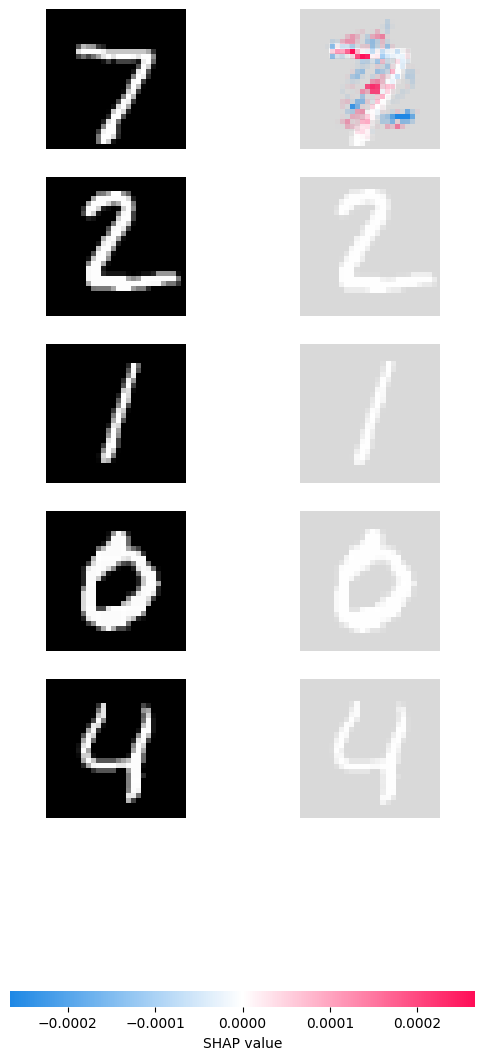

In [ ]:
# Install SHAP
%pip install shap

import shap
import numpy as np

# Select a subset of data for SHAP (DeepExplainer can be slow on large datasets)
# We use a background set for the explainer and a test set for explanation
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
test_images = X_test[0:5]

# Initialize DeepExplainer
explainer = shap.DeepExplainer(model, background)

# Compute SHAP values
shap_values = explainer.shap_values(test_images)

# The output format of shap_values changed in recent versions.
# It's usually a list of arrays (one per class) or a single array.
# Let's visualize the first test image across all classes
shap.image_plot(shap_values, test_images)

## Task 5: Comparison Analysis

| Feature | LIME | SHAP |
| :--- | :--- | :--- |
| **Consistency** | Can vary between runs due to random sampling. | More consistent as it is based on game theory (Shapley values). |
| **Computation Time** | Faster for single instances. | Slower, especially for deep networks or large backgrounds. |
| **Interpretability** | Easy to see 'superpixels' and boundaries. | Shows pixel-level influence, often more granular but noisier. |
| **Stability** | Locally stable but can be sensitive to kernel width. | Highly stable due to mathematical axioms (efficiency, symmetry). |

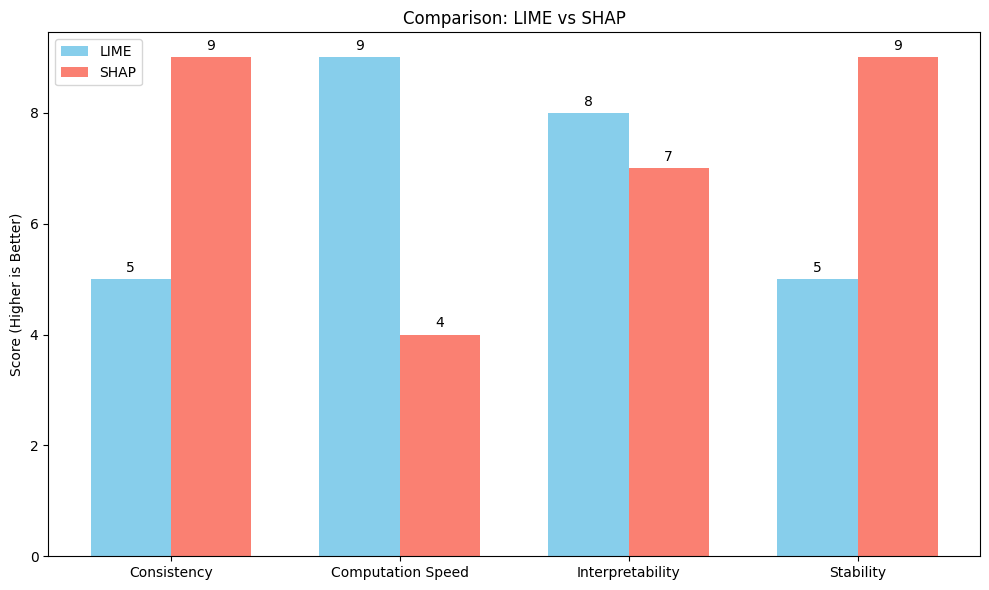

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data for comparison
metrics = ['Consistency', 'Computation Speed', 'Interpretability', 'Stability']
# Normalized scores (1-10, where 10 is best)
lime_scores = [5, 9, 8, 5]
shap_scores = [9, 4, 7, 9]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lime_scores, width, label='LIME', color='skyblue')
rects2 = ax.bar(x + width/2, shap_scores, width, label='SHAP', color='salmon')

ax.set_ylabel('Score (Higher is Better)')
ax.set_title('Comparison: LIME vs SHAP')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()